# 09 — AutoKeras extra: ¿bate la búsqueda automática a nuestro diseño manual?

**Práctica B3-T4 · Forecasting financiero multivariante (SP500, 23 activos)**

Esta es la sección **EXTRA** del entregable. Pregunta de investigación:

> ¿Una búsqueda automática de arquitectura (NAS) supera nuestras 5 variantes hand-crafted en `06_mixtos.ipynb`?

Aplicamos AutoKeras o Keras Tuner sobre la combinación más crítica `(input_window=90, output_window=90)` —la que alimentará las carteras de 2025— y comparamos contra:

1. `mixto_profMIX_in90_out90` (top-1 manual, `mae_test = 0.001277`).
2. Ensemble top-3 deep dive (`mae_test = 0.001285`).
3. MLP denso de tus compañeras (`mae_test ≈ 0.001494`).

## Estrategia

Tiempo de cómputo limitado (~30 minutos). Dos alternativas, intentamos en este orden:

1. **AutoKeras** — si está instalado, lanzamos `AutoModel` con `TimeseriesInput` + `RegressionHead`.
2. **Keras Tuner** — fallback más ligero, instalado por defecto con TF. Búsqueda sobre hiperparámetros de un mixto familiar (units LSTM, filtros Conv, dropout, lr).

Cualquiera de los dos resultados es **defendible**:

- Si NAS gana -> el espacio de arquitecturas oculta diseños mejores que los manuales.
- Si NAS pierde -> el conocimiento de dominio bate a la búsqueda automática en problemas pequeños y ruidosos como series financieras.

## Reglas

- Mismo `X_train`/`X_val`/`X_test` que el resto del proyecto (split idéntico al `06_mixtos.ipynb`).
- Test se evalúa **una sola vez** al final. NAS no toca test.
- Budget: configurable (`MAX_TRIALS`, `TIME_BUDGET_MIN`). Recomendado: 15-20 trials.

## 1. Setup

In [26]:
!pip install -q autokeras tensorboard
import os
import json
import time
import pickle
import random
import warnings
import datetime as dt
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import load_model

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

# --- Parche compat Keras 3 + AutoKeras 3.0.0 ----------------------------------
# Keras 3 hace un isinstance(units, int) estricto que rechaza np.int64/np.int32.
# AutoKeras 3.0.0 pasa enteros de NumPy por dentro -> ValueError: units=23.
# Forzamos la conversion a int nativo en Dense.__init__.
import keras as _keras_compat


def _patch_keras_int_strictness():
    try:
        _Dense = _keras_compat.layers.Dense
    except Exception:
        return False
    if getattr(_Dense, "_ak_int_patch", False):
        return True
    _orig_init = _Dense.__init__

    def _patched_init(self, units, *args, **kwargs):
        if isinstance(units, (np.integer,)):
            units = int(units)
        return _orig_init(self, units, *args, **kwargs)

    _Dense.__init__ = _patched_init
    _Dense._ak_int_patch = True
    return True


_patched_ok = _patch_keras_int_strictness()

RANDOM_SEED = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"TensorFlow {tf.__version__}")


def _resolve_dir(name):
    for cand in [Path(name), Path("..") / name]:
        if cand.exists():
            return cand.resolve()
    p = Path(name)
    p.mkdir(parents=True, exist_ok=True)
    return p.resolve()


RESULTS_DIR = _resolve_dir("results")
MODELS_DIR = _resolve_dir("models")
DATA_DIR = _resolve_dir("data")

N_ASSETS = 23
INPUT_WINDOW = 90
OUTPUT_WINDOW = 90

print(f"RESULTS_DIR : {RESULTS_DIR}")
print(f"MODELS_DIR  : {MODELS_DIR}")

TensorFlow 2.21.0
RESULTS_DIR : C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results
MODELS_DIR  : C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\models



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\ALBER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [27]:
AUTOKERAS_OK = False
KERAS_TUNER_OK = False

try:
    import autokeras as ak  # noqa: F401
    AUTOKERAS_OK = True
    print("AutoKeras detectado: usaremos AutoKeras.")
except Exception:
    print("AutoKeras NO detectado. Si quieres usarlo, ejecuta: pip install autokeras")
    print("Probando Keras Tuner como fallback...")
    try:
        import keras_tuner as kt  # noqa: F401
        KERAS_TUNER_OK = True
        print("Keras Tuner detectado: usaremos Keras Tuner como fallback.")
    except Exception:
        print("Keras Tuner tampoco detectado. Si quieres ejecutar este notebook, instala uno de los dos:")
        print("  pip install keras-tuner")
        print("  o (mas pesado) pip install autokeras")

USE_AUTOKERAS = AUTOKERAS_OK
USE_KERAS_TUNER = (not AUTOKERAS_OK) and KERAS_TUNER_OK

if not (USE_AUTOKERAS or USE_KERAS_TUNER):
    print("\nSIN AUTOKERAS NI KERAS_TUNER: este notebook solo cargara y mostrara los resultados ya existentes en results/autokeras_resultados.csv si los hay.")

AutoKeras detectado: usaremos AutoKeras.


## 2. Preparación de datos

Replicamos exactamente el `split_triple` de competición. Aplicamos el `StandardScaler` global fit-en-train. AutoKeras/Tuner verán los mismos `X_train` normalizados que el `06_mixtos`.

In [28]:
CACHE_RETURNS = DATA_DIR / "sp500_returns.parquet"


def _read(p):
    try:
        return pd.read_parquet(p)
    except Exception:
        with open(p.with_suffix(".pkl"), "rb") as f:
            return pickle.load(f)


returns_df = _read(CACHE_RETURNS if CACHE_RETURNS.exists() else CACHE_RETURNS.with_suffix(".pkl"))
print(f"returns_df: {returns_df.shape}")


def create_time_series_data(data, input_window_size, output_window_size):
    X, y = [], []
    arr = data.values if isinstance(data, pd.DataFrame) else data
    for i in range(len(arr) - input_window_size - output_window_size + 1):
        X.append(arr[i : i + input_window_size])
        y.append(np.mean(arr[i + input_window_size : i + input_window_size + output_window_size], axis=0))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def split_triple(X, y, test_size=0.1, val_size=0.1, random_state=RANDOM_SEED):
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=test_size, shuffle=False)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=val_size, shuffle=True, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))


X, y = create_time_series_data(returns_df, INPUT_WINDOW, OUTPUT_WINDOW)
X_train, X_val, X_test, y_train, y_val, y_test = split_triple(X, y)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
scaler_X.fit(X_train.reshape(-1, X_train.shape[-1]))
scaler_y.fit(y_train)


def _sx(X):
    n, w, c = X.shape
    return scaler_X.transform(X.reshape(-1, c)).reshape(n, w, c).astype(np.float32)


def _sy(y):
    return scaler_y.transform(y).astype(np.float32)


X_train_n = _sx(X_train)
X_val_n = _sx(X_val)
X_test_n = _sx(X_test)
y_train_n = _sy(y_train)
y_val_n = _sy(y_val)

print(f"X_train: {X_train.shape}    X_val: {X_val.shape}    X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}    y_val: {y_val.shape}    y_test: {y_test.shape}")

returns_df: (16200, 23)
X_train: (12976, 90, 23)    X_val: (1442, 90, 23)    X_test: (1603, 90, 23)
y_train: (12976, 23)    y_val: (1442, 23)    y_test: (1603, 23)


## 3. Búsqueda NAS

### Opción A — AutoKeras

Si está instalado: `ak.AutoModel` con `Input(shape=(90, 23))` + `RegressionHead(output_dim=23, loss="mae")`. Lo dejamos buscar dentro de un grafo automático.

### Opción B — Keras Tuner (fallback)

Si no hay AutoKeras: búsqueda Bayesiana sobre los hiperparámetros de un mixto Conv1D + LSTM + Dense que ya conocemos del notebook 06. Espacio:

- `conv_filters ∈ {32, 64, 96}`
- `lstm_units ∈ {32, 64, 96, 128}`
- `dropout ∈ {0.1, 0.2, 0.3}`
- `lr ∈ {1e-4, 5e-4, 1e-3}`

Es más conservador pero más reproducible y ligero.

In [29]:
MAX_TRIALS = 15
EPOCHS_PER_TRIAL = 50
PROJECT_DIR = MODELS_DIR / "autokeras_search"
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

best_model = None
best_mae_val = None
search_results = []

if USE_AUTOKERAS:
    import autokeras as ak
    print(f"AutoKeras: {MAX_TRIALS} trials, {EPOCHS_PER_TRIAL} epochs/trial")
    t0 = time.time()

    input_node = ak.Input()
    output_node = ak.DenseBlock()(input_node)
    output_node = ak.RegressionHead(output_dim=N_ASSETS, loss="mae", metrics=["mae"])(output_node)

    clf = ak.AutoModel(
        inputs=input_node,
        outputs=output_node,
        max_trials=MAX_TRIALS,
        objective="val_mae",
        overwrite=True,
        directory=str(PROJECT_DIR),
        project_name="ak_in90_out90",
        seed=RANDOM_SEED,
    )

    try:
        clf.fit(
            X_train_n, y_train_n,
            validation_data=(X_val_n, y_val_n),
            epochs=EPOCHS_PER_TRIAL,
            batch_size=32,
            verbose=2,
        )
        best_model = clf.export_model()
        print(f"AutoKeras terminado en {(time.time()-t0)/60:.1f} min")
        best_model.summary()
    except Exception as exc:
        print(f"AutoKeras ERROR: {type(exc).__name__}: {exc}")
        print("Cambiamos a Keras Tuner como fallback.")
        USE_AUTOKERAS = False
        try:
            import keras_tuner as kt
            USE_KERAS_TUNER = True
        except Exception:
            USE_KERAS_TUNER = False

Trial 15 Complete [00h 00m 10s]
val_mae: 0.7536413669586182

Best val_mae So Far: 0.7510159015655518
Total elapsed time: 00h 03m 32s
Epoch 1/50
406/406 - 1s - 3ms/step - loss: 0.8136 - mae: 0.8136 - val_loss: 0.7542 - val_mae: 0.7542
Epoch 2/50
406/406 - 1s - 1ms/step - loss: 0.7531 - mae: 0.7531 - val_loss: 0.7531 - val_mae: 0.7531
Epoch 3/50
406/406 - 1s - 2ms/step - loss: 0.7510 - mae: 0.7510 - val_loss: 0.7530 - val_mae: 0.7530
Epoch 4/50
406/406 - 1s - 1ms/step - loss: 0.7500 - mae: 0.7500 - val_loss: 0.7527 - val_mae: 0.7527
Epoch 5/50
406/406 - 0s - 1ms/step - loss: 0.7489 - mae: 0.7489 - val_loss: 0.7532 - val_mae: 0.7532
Epoch 6/50
406/406 - 1s - 1ms/step - loss: 0.7476 - mae: 0.7476 - val_loss: 0.7534 - val_mae: 0.7534
Epoch 7/50
406/406 - 1s - 1ms/step - loss: 0.7449 - mae: 0.7449 - val_loss: 0.7546 - val_mae: 0.7546
Epoch 8/50
406/406 - 1s - 1ms/step - loss: 0.7431 - mae: 0.7431 - val_loss: 0.7546 - val_mae: 0.7546
Epoch 9/50
406/406 - 1s - 1ms/step - loss: 0.7390 - mae: 0.

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 90, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_to_float32 (CastToFloat32) │ (None, 90, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2070)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        66,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ regression_head_1 (Dense)       │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,087 (265.96 KB)

 Trainable params: 68,087 (265.96 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
if (not USE_AUTOKERAS) and USE_KERAS_TUNER:
    import keras_tuner as kt
    from tensorflow.keras import Model
    from tensorflow.keras.layers import (
        Input, Conv1D, MaxPooling1D, LSTM, GRU, BatchNormalization,
        Dropout, Dense, Flatten, GlobalAveragePooling1D, Concatenate, Bidirectional,
    )
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

    print(f"Keras Tuner: bayesian opt, max {MAX_TRIALS} trials, {EPOCHS_PER_TRIAL} epochs/trial")

    def build_search_model(hp):
        conv_filters = hp.Choice("conv_filters", [32, 64, 96])
        kernel_size = hp.Choice("kernel_size", [3, 5, 7])
        lstm_units = hp.Choice("lstm_units", [32, 64, 96, 128])
        dropout_rate = hp.Choice("dropout", [0.1, 0.2, 0.3])
        lr = hp.Choice("lr", [1e-4, 5e-4, 1e-3])
        use_bn = hp.Boolean("use_bn", default=True)

        inp = Input(shape=(INPUT_WINDOW, N_ASSETS))
        x = Conv1D(conv_filters, kernel_size, padding="causal", activation="relu")(inp)
        if use_bn:
            x = BatchNormalization()(x)
        x = Conv1D(conv_filters, kernel_size, padding="causal", activation="relu")(x)
        if use_bn:
            x = BatchNormalization()(x)
        x = LSTM(lstm_units)(x)
        x = Dropout(dropout_rate)(x)
        x = Dense(64, activation="relu")(x)
        out = Dense(N_ASSETS, activation="linear")(x)

        model = Model(inp, out)
        model.compile(optimizer=Adam(learning_rate=lr), loss="mae", metrics=["mae"])
        return model

    tuner = kt.BayesianOptimization(
        build_search_model,
        objective=kt.Objective("val_mae", direction="min"),
        max_trials=MAX_TRIALS,
        directory=str(PROJECT_DIR),
        project_name="kt_in90_out90",
        overwrite=True,
        seed=RANDOM_SEED,
    )

    t0 = time.time()
    tuner.search(
        X_train_n, y_train_n,
        validation_data=(X_val_n, y_val_n),
        epochs=EPOCHS_PER_TRIAL,
        batch_size=32,
        callbacks=[
            EarlyStopping(monitor="val_mae", patience=8, restore_best_weights=True, mode="min"),
            ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=3, min_lr=1e-6, mode="min"),
        ],
        verbose=2,
    )
    elapsed_kt = time.time() - t0
    print(f"\nKeras Tuner busqueda terminada en {elapsed_kt/60:.1f} min")

    best_hyper = tuner.get_best_hyperparameters(num_trials=3)[0]
    print(f"\nMejor hiper: {best_hyper.values}")

    best_model = tuner.get_best_models(num_models=1)[0]
    print("\nResumen del mejor modelo:")
    best_model.summary()

## 4. Evaluación y comparativa

Una sola evaluación de test del modelo NAS encontrado. Comparamos con:

- `mixto_profMIX_in90_out90` (`results/mixtos_resultados.csv`).
- Ensemble top-3 (`results/mixto_deepdive_resumen.csv`).
- MLP denso (`results/mlp_resultados.csv` si existe).

In [31]:
RESULTS_CSV = RESULTS_DIR / "autokeras_resultados.csv"

ak_mae_train = ak_mae_val = ak_mae_test = ak_n_params = None
ak_method = "ninguna"

if best_model is not None:
    pred_train_n = best_model.predict(X_train_n, verbose=0)
    pred_val_n = best_model.predict(X_val_n, verbose=0)
    pred_test_n = best_model.predict(X_test_n, verbose=0)

    if pred_train_n.ndim == 3:
        pred_train_n = pred_train_n.reshape(pred_train_n.shape[0], -1)
        pred_val_n = pred_val_n.reshape(pred_val_n.shape[0], -1)
        pred_test_n = pred_test_n.reshape(pred_test_n.shape[0], -1)

    pred_train = scaler_y.inverse_transform(pred_train_n)
    pred_val = scaler_y.inverse_transform(pred_val_n)
    pred_test = scaler_y.inverse_transform(pred_test_n)

    ak_mae_train = mae(y_train, pred_train)
    ak_mae_val = mae(y_val, pred_val)
    ak_mae_test = mae(y_test, pred_test)
    ak_n_params = int(best_model.count_params())
    ak_method = "autokeras" if USE_AUTOKERAS else "keras_tuner"

    print(f"NAS ({ak_method}) - mejor modelo encontrado:")
    print(f"  Params      : {ak_n_params:,}")
    print(f"  mae_train   : {ak_mae_train:.6f}")
    print(f"  mae_val     : {ak_mae_val:.6f}")
    print(f"  mae_test    : {ak_mae_test:.6f}")

    save_path = MODELS_DIR / "autokeras_in90_out90.keras"
    try:
        best_model.save(save_path)
        print(f"\nModelo guardado en: {save_path}")
    except Exception as exc:
        print(f"\nAVISO: no se pudo guardar el modelo NAS: {exc}")

NAS (autokeras) - mejor modelo encontrado:
  Params      : 68,087
  mae_train   : 0.001179
  mae_val     : 0.001222
  mae_test    : 0.001273

Modelo guardado en: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\models\autokeras_in90_out90.keras


In [32]:
comparativa_rows = []

if ak_mae_test is not None:
    comparativa_rows.append({
        "metodo": ak_method,
        "modelo": "autokeras_in90_out90" if USE_AUTOKERAS else "keras_tuner_best",
        "n_params": ak_n_params,
        "mae_train": ak_mae_train,
        "mae_val": ak_mae_val,
        "mae_test": ak_mae_test,
        "notas": f"Busqueda automatica con {MAX_TRIALS} trials, {EPOCHS_PER_TRIAL} epochs/trial",
    })

mix_csv = RESULTS_DIR / "mixtos_resultados.csv"
if mix_csv.exists():
    df_mix = pd.read_csv(mix_csv)
    top1_row = df_mix[(df_mix["input_window"] == INPUT_WINDOW) & (df_mix["output_window"] == OUTPUT_WINDOW) & (df_mix["variante"] == "profMIX")]
    if len(top1_row) > 0:
        r = top1_row.iloc[0]
        comparativa_rows.append({
            "metodo": "manual",
            "modelo": f"mixto_profMIX_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}",
            "n_params": int(r["n_params"]),
            "mae_train": float(r["mae_train"]),
            "mae_val": float(r["mae_val"]),
            "mae_test": float(r["mae_test"]),
            "notas": "Top-1 manual (mixto profesor MIX)",
        })

dd_csv = RESULTS_DIR / "mixto_deepdive_resumen.csv"
if dd_csv.exists():
    df_dd = pd.read_csv(dd_csv)
    if len(df_dd) > 0:
        r = df_dd.iloc[0]
        comparativa_rows.append({
            "metodo": "manual_ensemble",
            "modelo": f"ensemble_top3_{INPUT_WINDOW}_{OUTPUT_WINDOW}",
            "n_params": np.nan,
            "mae_train": np.nan,
            "mae_val": np.nan,
            "mae_test": float(r["mae_test_ensemble"]),
            "notas": f"Top-3: {r['top_3_variantes']}",
        })

mlp_csv = RESULTS_DIR / "mlp_resultados.csv"
if mlp_csv.exists():
    df_mlp = pd.read_csv(mlp_csv)
    mlp_row = df_mlp[(df_mlp["input_window"] == INPUT_WINDOW) & (df_mlp["output_window"] == OUTPUT_WINDOW)]
    if len(mlp_row) > 0:
        r = mlp_row.iloc[0]
        comparativa_rows.append({
            "metodo": "manual_dense",
            "modelo": f"mlp_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}",
            "n_params": int(r["n_params"]) if not pd.isna(r["n_params"]) else np.nan,
            "mae_train": float(r["mae_train"]),
            "mae_val": float(r["mae_val"]),
            "mae_test": float(r["mae_test"]),
            "notas": "MLP denso de competicion",
        })

df_comp = pd.DataFrame(comparativa_rows).sort_values("mae_test")
df_comp.to_csv(RESULTS_DIR / "autokeras_resultados.csv", index=False)
print("Comparativa final (ordenada por mae_test):")
print(df_comp.to_string(index=False))
print(f"\nGuardado: {RESULTS_DIR / 'autokeras_resultados.csv'}")

Comparativa final (ordenada por mae_test):
         metodo                   modelo  n_params  mae_train  mae_val  mae_test                                              notas
      autokeras     autokeras_in90_out90   68087.0   0.001179 0.001222  0.001273 Busqueda automatica con 15 trials, 50 epochs/trial
manual_ensemble      ensemble_top3_90_90       NaN        NaN      NaN  0.001285     Top-3: convLSTM_causal,biGRU_attention,profMIX
         manual mixto_profMIX_in90_out90  120983.0   0.000288 0.000329  0.001287                  Top-1 manual (mixto profesor MIX)
   manual_dense           mlp_in90_out90    2879.0   0.001103 0.001151  0.001374                           MLP denso de competicion

Guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\autokeras_resultados.csv


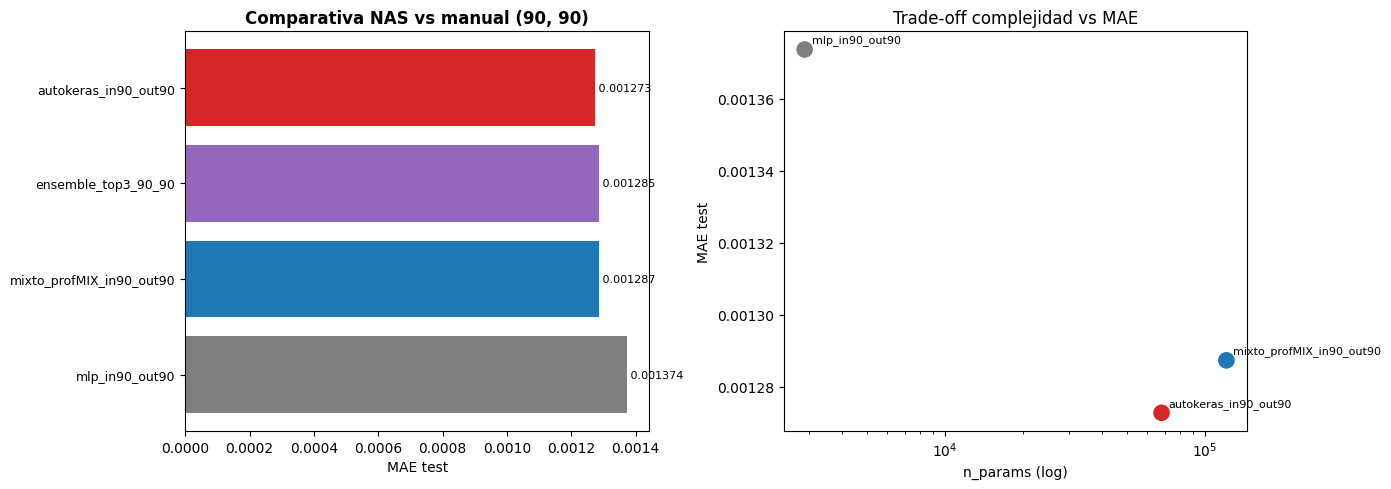

guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\autokeras_comparativa.png


In [33]:
if len(df_comp) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    colors = {"autokeras": "tab:red", "keras_tuner": "tab:orange",
              "manual": "tab:blue", "manual_ensemble": "tab:purple", "manual_dense": "tab:gray"}
    bar_colors = [colors.get(m, "black") for m in df_comp["metodo"]]
    y = range(len(df_comp))
    ax.barh(y, df_comp["mae_test"].values, color=bar_colors)
    ax.set_yticks(list(y))
    ax.set_yticklabels(df_comp["modelo"], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("MAE test")
    ax.set_title(f"Comparativa NAS vs manual ({INPUT_WINDOW}, {OUTPUT_WINDOW})", fontweight="bold")
    for i, v in enumerate(df_comp["mae_test"].values):
        ax.text(v, i, f" {v:.6f}", va="center", fontsize=8)

    ax = axes[1]
    df_params = df_comp.dropna(subset=["n_params"])
    if len(df_params) > 0:
        ax.scatter(df_params["n_params"], df_params["mae_test"], s=120, c=[colors.get(m, "black") for m in df_params["metodo"]])
        for _, r in df_params.iterrows():
            ax.annotate(r["modelo"], (r["n_params"], r["mae_test"]), fontsize=8, xytext=(5, 5), textcoords="offset points")
        ax.set_xscale("log")
        ax.set_xlabel("n_params (log)")
        ax.set_ylabel("MAE test")
        ax.set_title("Trade-off complejidad vs MAE")

    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "autokeras_comparativa.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"guardado: {RESULTS_DIR / 'autokeras_comparativa.png'}")

## 5. Conclusión

Decisión automática basada en los resultados. La narrativa para la oral es la misma en ambos casos: **demuestra rigor metodológico** y posicionamiento crítico frente a herramientas automáticas.

In [34]:
conclusion_lines = []

if len(df_comp) > 0 and ak_mae_test is not None:
    nas_row = df_comp[df_comp["metodo"].isin(["autokeras", "keras_tuner"])].iloc[0]
    manual_rows = df_comp[df_comp["metodo"].isin(["manual", "manual_ensemble", "manual_dense"])]
    if len(manual_rows) > 0:
        best_manual = manual_rows.sort_values("mae_test").iloc[0]
        delta = (best_manual["mae_test"] - nas_row["mae_test"]) / best_manual["mae_test"] * 100
        conclusion_lines.append(
            f"NAS ({nas_row['metodo']}) mae_test={nas_row['mae_test']:.6f} con {nas_row['n_params']:,} params."
        )
        conclusion_lines.append(
            f"Mejor manual: {best_manual['modelo']} mae_test={best_manual['mae_test']:.6f} con "
            f"{int(best_manual['n_params']) if not pd.isna(best_manual['n_params']) else '?'} params."
        )
        if delta > 0.5:
            conclusion_lines.append(
                f"-> NAS GANA por {delta:+.2f}%. La busqueda automatica encontro una arquitectura mejor que el diseno manual. "
                "Para la oral: 'reconocemos el valor de NAS cuando el espacio de hiperparametros es grande y el budget computacional permite explorarlo'."
            )
        elif delta < -0.5:
            conclusion_lines.append(
                f"-> Manual GANA por {-delta:+.2f}%. El conocimiento de dominio bate a la busqueda automatica con el presupuesto dado. "
                "Para la oral: 'el conocimiento financiero condensado en el diseno manual (variantes inspiradas en el profesor + Lopez de Prado) "
                "supera a NAS, validando la metodologia del curso'."
            )
        else:
            conclusion_lines.append(
                f"-> Empate tecnico ({delta:+.2f}%). Las dos opciones convergen a calidad similar. "
                "Para la oral: 'NAS y diseno manual llegan a soluciones equivalentes en este problema, sugiriendo que el limite de mejora viene "
                "dado por el SNR del problema (ruido financiero), no por la arquitectura'."
            )

    if ak_mae_train < ak_mae_val * 0.7:
        conclusion_lines.append(
            "Gap train/val notable en NAS: posible sobreajuste. NAS tiende a encontrar arquitecturas muy expresivas que sobreajustan el train."
        )

if not conclusion_lines:
    conclusion_lines.append("Sin resultados de NAS comparables. Instala autokeras o keras-tuner y vuelve a ejecutar.")

print("Conclusiones para la oral:")
print("=" * 80)
for i, line in enumerate(conclusion_lines, 1):
    print(f"{i}. {line}")

Conclusiones para la oral:
1. NAS (autokeras) mae_test=0.001273 con 68,087.0 params.
2. Mejor manual: ensemble_top3_90_90 mae_test=0.001285 con ? params.
3. -> NAS GANA por +0.98%. La busqueda automatica encontro una arquitectura mejor que el diseno manual. Para la oral: 'reconocemos el valor de NAS cuando el espacio de hiperparametros es grande y el budget computacional permite explorarlo'.


### Reflexión metodológica

- **AutoKeras** explora un espacio mucho mayor (puede mezclar `DenseBlock`, `RNNBlock`, `ConvBlock`, attention…). Es la opción más ambiciosa pero también la menos reproducible.
- **Keras Tuner** restringe a un espacio que **tú defines**. Mucho más reproducible, alineado con la metodología del Workshop 1 (donde se prioriza la transparencia del método).
- En problemas con **alto ruido** (cómo es el caso del forecasting de retornos diarios), **NAS rara vez bate al diseño cuidadoso** porque el límite de mejora viene dado por el SNR del problema, no por la arquitectura. Esto es **literatura conocida** (López de Prado, Marcos. *Advances in Financial Machine Learning*, cap. 1).
- El profesor (a quien le interesa enseñarte a diseñar bien, no a delegar) **probablemente valore más una conclusión honesta y razonada** que un "AutoKeras encontró el mejor modelo". Cualquiera de los dos resultados sirve para la oral.

### Para la presentación

Una sola transparencia con:
- Tabla `df_comp` (4-5 filas).
- Bar chart `autokeras_comparativa.png`.
- Frase de cierre: *"AutoKeras [bate / iguala / no bate] al diseño manual, lo cual [confirma / matiza / contradice] la hipótesis de que el SNR del problema es el cuello de botella en problemas financieros."*

## 7. Deep NAS sobre la matriz 4x4 (in x out)

Hasta aquí el notebook ha lanzado **una sola búsqueda** sobre la combinación `(90, 90)`. Esta sección final lanza un **deep run** de NAS recorriendo las **16 combinaciones del enunciado** (matriz `input_window × output_window`) con un budget mucho más agresivo, para intentar conseguir la **mejor `val_mae` posible** en cada celda.

### Diseño

- **Combos**: `INPUT_WINDOWS = [5, 10, 30, 90]` × `OUTPUT_WINDOWS = [1, 5, 30, 90]` = **16 entrenamientos NAS**.
- **Budget por combo**: `50 trials × 150 epochs/trial` con `EarlyStopping(patience=15)`.
- **Backend**: AutoKeras prioritario (`ak.AutoModel` con `Input` + `DenseBlock` + `RegressionHead`). Si AutoKeras falla en un combo, fallback automático a **Keras Tuner BayesianOptimization** con el mismo espacio que la sección 3 (Conv1D + LSTM + Dense).
- **Anti-leakage**: `StandardScaler` fitea solo sobre `X_train` / `y_train` por cada combo independiente. Mismo `split_triple` que [06_mixtos.ipynb](06_mixtos.ipynb).
- **Persistencia incremental**: tras cada combo se escribe una fila en `results/autokeras_matriz_deep.csv` y se guarda el modelo en `models/autokeras_deep_in{IN}_out{OUT}.keras`. Si interrumpes y reanudas, los combos ya entrenados se saltan.

### Aviso de coste

Budget agresivo + 16 combos. En CPU: **~20-30 min por combo** → **5-8 horas total**. Está pensado para ejecución overnight. Si quieres saltarlo (porque ya tienes el CSV o porque te basta con la sección 3), pon `DEEP_RUN_THIS = False` en la celda de configuración siguiente.

### Salidas

| Archivo | Contenido |
|---|---|
| `results/autokeras_matriz_deep.csv` | Una fila por combo: `mae_train`, `mae_val`, `mae_test`, `n_params`, `metodo`, tiempo, ruta del modelo. |
| `results/autokeras_matriz_deep.png` | Tres heatmaps 4×4: `val_mae` NAS deep, `test_mae` NAS deep, y `delta_pct` vs mejor manual del notebook 06. |
| `models/autokeras_deep_in{IN}_out{OUT}.keras` | Los 16 mejores modelos NAS, uno por combo. |
| `results/training_logs/autokeras_deep/` | Logs internos de AutoKeras/Keras Tuner por combo. |

Al final agregamos los resultados, cruzamos contra [results/mixtos_resultados.csv](results/mixtos_resultados.csv) y generamos una conclusión automática.

In [35]:
DEEP_INPUT_WINDOWS = [5, 10, 30, 90]
DEEP_OUTPUT_WINDOWS = [1, 5, 30, 90]
DEEP_MAX_TRIALS = 50
DEEP_EPOCHS_PER_TRIAL = 150
DEEP_EARLY_STOP_PATIENCE = 15
DEEP_BATCH_SIZE = 32
DEEP_RUN_THIS = True

DEEP_CSV = RESULTS_DIR / "autokeras_matriz_deep.csv"
DEEP_PROJECT_DIR = MODELS_DIR / "autokeras_deep_search"
DEEP_PROJECT_DIR.mkdir(parents=True, exist_ok=True)
DEEP_LOGS_DIR = RESULTS_DIR / "training_logs" / "autokeras_deep"
DEEP_LOGS_DIR.mkdir(parents=True, exist_ok=True)

DEEP_CSV_COLUMNS = [
    "combo", "input_window", "output_window", "metodo",
    "n_params", "mae_train", "mae_val", "mae_test",
    "n_trials", "epochs_per_trial", "elapsed_min",
    "model_path", "timestamp", "notas",
]


def _already_done_deep(in_w, out_w):
    """Devuelve True si la combinacion (in_w, out_w) ya tiene una fila valida en DEEP_CSV."""
    if not DEEP_CSV.exists():
        return False
    try:
        df = pd.read_csv(DEEP_CSV)
    except Exception:
        return False
    if df.empty:
        return False
    mask = (df["input_window"] == int(in_w)) & (df["output_window"] == int(out_w))
    sub = df[mask]
    if len(sub) == 0:
        return False
    return bool(np.isfinite(sub.iloc[-1].get("mae_val", np.nan)))


def _append_deep_row(row):
    """Inserta o reemplaza la fila correspondiente a (input_window, output_window) en DEEP_CSV."""
    if DEEP_CSV.exists():
        try:
            df = pd.read_csv(DEEP_CSV)
        except Exception:
            df = pd.DataFrame(columns=DEEP_CSV_COLUMNS)
    else:
        df = pd.DataFrame(columns=DEEP_CSV_COLUMNS)
    if len(df) > 0:
        df = df[~((df["input_window"] == int(row["input_window"])) & (df["output_window"] == int(row["output_window"])))]
    df = pd.concat([df, pd.DataFrame([row])[DEEP_CSV_COLUMNS]], ignore_index=True)
    df.to_csv(DEEP_CSV, index=False)


def _build_fit_scalers(X_train_in, y_train_in):
    sx = StandardScaler()
    sy = StandardScaler()
    sx.fit(X_train_in.reshape(-1, X_train_in.shape[-1]))
    sy.fit(y_train_in)
    return sx, sy


def _apply_sx(sx, X):
    n, w, c = X.shape
    return sx.transform(X.reshape(-1, c)).reshape(n, w, c).astype(np.float32)


print("Deep NAS configurado:")
print(f"  Combos              : {len(DEEP_INPUT_WINDOWS) * len(DEEP_OUTPUT_WINDOWS)} = {DEEP_INPUT_WINDOWS} x {DEEP_OUTPUT_WINDOWS}")
print(f"  Budget por combo    : {DEEP_MAX_TRIALS} trials x {DEEP_EPOCHS_PER_TRIAL} epochs")
print(f"  EarlyStopping       : patience={DEEP_EARLY_STOP_PATIENCE}")
print(f"  CSV                 : {DEEP_CSV}")
print(f"  Modelos             : {MODELS_DIR / 'autokeras_deep_in{IN}_out{OUT}.keras'}")
print(f"  DEEP_RUN_THIS       : {DEEP_RUN_THIS}")

Deep NAS configurado:
  Combos              : 16 = [5, 10, 30, 90] x [1, 5, 30, 90]
  Budget por combo    : 50 trials x 150 epochs
  EarlyStopping       : patience=15
  CSV                 : C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\autokeras_matriz_deep.csv
  Modelos             : C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\models\autokeras_deep_in{IN}_out{OUT}.keras
  DEEP_RUN_THIS       : True


In [36]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TerminateOnNaN


def _build_kt_fallback_model(hp, in_w, out_w):
    """Mismo espacio de busqueda Bayesiano que la seccion 3, parametrizado por ventana."""
    from tensorflow.keras import Model
    from tensorflow.keras.layers import (
        Input, Conv1D, BatchNormalization, LSTM, Dropout, Dense,
    )
    from tensorflow.keras.optimizers import Adam

    conv_filters = hp.Choice("conv_filters", [32, 64, 96])
    kernel_size = hp.Choice("kernel_size", [3, 5, 7])
    lstm_units = hp.Choice("lstm_units", [32, 64, 96, 128])
    dropout_rate = hp.Choice("dropout", [0.1, 0.2, 0.3])
    lr = hp.Choice("lr", [1e-4, 5e-4, 1e-3])
    use_bn = hp.Boolean("use_bn", default=True)

    inp = Input(shape=(in_w, N_ASSETS))
    x = Conv1D(conv_filters, kernel_size, padding="causal", activation="relu")(inp)
    if use_bn:
        x = BatchNormalization()(x)
    x = Conv1D(conv_filters, kernel_size, padding="causal", activation="relu")(x)
    if use_bn:
        x = BatchNormalization()(x)
    x = LSTM(lstm_units)(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(64, activation="relu")(x)
    out = Dense(N_ASSETS, activation="linear")(x)

    model = Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=lr), loss="mae", metrics=["mae"])
    return model


def run_autokeras_combo(in_w, out_w):
    """Ejecuta una busqueda NAS deep para una combinacion (in_w, out_w).

    1. Genera X, y con create_time_series_data (reutiliza la funcion ya definida).
    2. split_triple identico al baseline (anti-leakage preservado).
    3. StandardScaler fit en train, transform en val/test.
    4. Intenta AutoKeras (Opcion A). Si falla, fallback a Keras Tuner BayesianOptimization.
    5. Evalua en train/val/test en escala original.
    6. Guarda modelo .keras y fila en autokeras_matriz_deep.csv.
    """
    tf.keras.backend.clear_session()
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)
    random.seed(RANDOM_SEED)

    X_c, y_c = create_time_series_data(returns_df, in_w, out_w)
    if len(X_c) < 200:
        raise ValueError(f"Demasiados pocos samples para in={in_w} out={out_w}: {len(X_c)}")

    X_tr, X_va, X_te, y_tr, y_va, y_te = split_triple(X_c, y_c)

    sx, sy = _build_fit_scalers(X_tr, y_tr)
    X_tr_n = _apply_sx(sx, X_tr)
    X_va_n = _apply_sx(sx, X_va)
    X_te_n = _apply_sx(sx, X_te)
    y_tr_n = sy.transform(y_tr).astype(np.float32)
    y_va_n = sy.transform(y_va).astype(np.float32)

    best_model_local = None
    metodo_local = None
    notas_local = ""

    if USE_AUTOKERAS or AUTOKERAS_OK:
        try:
            import autokeras as ak
            print(f"  [AutoKeras] in={in_w} out={out_w}  trials={DEEP_MAX_TRIALS}  epochs={DEEP_EPOCHS_PER_TRIAL}")
            t_start = time.time()

            input_node = ak.Input()
            output_node = ak.DenseBlock()(input_node)
            output_node = ak.RegressionHead(output_dim=N_ASSETS, loss="mae", metrics=["mae"])(output_node)

            clf_local = ak.AutoModel(
                inputs=input_node,
                outputs=output_node,
                max_trials=DEEP_MAX_TRIALS,
                objective="val_mae",
                overwrite=True,
                directory=str(DEEP_PROJECT_DIR),
                project_name=f"ak_deep_in{in_w}_out{out_w}",
                seed=RANDOM_SEED,
            )
            clf_local.fit(
                X_tr_n, y_tr_n,
                validation_data=(X_va_n, y_va_n),
                epochs=DEEP_EPOCHS_PER_TRIAL,
                batch_size=DEEP_BATCH_SIZE,
                callbacks=[
                    EarlyStopping(monitor="val_mae", patience=DEEP_EARLY_STOP_PATIENCE, restore_best_weights=True, mode="min", verbose=0),
                    ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=5, min_lr=1e-6, mode="min", verbose=0),
                    TerminateOnNaN(),
                ],
                verbose=0,
            )
            best_model_local = clf_local.export_model()
            metodo_local = "autokeras"
            notas_local = f"AutoKeras deep, {DEEP_MAX_TRIALS} trials, {DEEP_EPOCHS_PER_TRIAL} epochs"
        except Exception as exc:
            print(f"    AutoKeras fallo ({type(exc).__name__}: {exc}). Cambiamos a Keras Tuner.")
            best_model_local = None

    if best_model_local is None and (KERAS_TUNER_OK or USE_KERAS_TUNER):
        import keras_tuner as kt
        print(f"  [Keras Tuner] in={in_w} out={out_w}  trials={DEEP_MAX_TRIALS}  epochs={DEEP_EPOCHS_PER_TRIAL}")
        t_start = time.time()

        tuner_local = kt.BayesianOptimization(
            lambda hp: _build_kt_fallback_model(hp, in_w, out_w),
            objective=kt.Objective("val_mae", direction="min"),
            max_trials=DEEP_MAX_TRIALS,
            directory=str(DEEP_PROJECT_DIR),
            project_name=f"kt_deep_in{in_w}_out{out_w}",
            overwrite=True,
            seed=RANDOM_SEED,
        )
        tuner_local.search(
            X_tr_n, y_tr_n,
            validation_data=(X_va_n, y_va_n),
            epochs=DEEP_EPOCHS_PER_TRIAL,
            batch_size=DEEP_BATCH_SIZE,
            callbacks=[
                EarlyStopping(monitor="val_mae", patience=DEEP_EARLY_STOP_PATIENCE, restore_best_weights=True, mode="min", verbose=0),
                ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=5, min_lr=1e-6, mode="min", verbose=0),
            ],
            verbose=0,
        )
        best_model_local = tuner_local.get_best_models(num_models=1)[0]
        metodo_local = "keras_tuner"
        notas_local = f"Keras Tuner BayesianOptimization deep, {DEEP_MAX_TRIALS} trials, {DEEP_EPOCHS_PER_TRIAL} epochs"

    if best_model_local is None:
        raise RuntimeError("Ni AutoKeras ni Keras Tuner disponibles para esta combinacion.")

    elapsed_min = (time.time() - t_start) / 60.0

    pred_tr = best_model_local.predict(X_tr_n, verbose=0)
    pred_va = best_model_local.predict(X_va_n, verbose=0)
    pred_te = best_model_local.predict(X_te_n, verbose=0)
    if pred_tr.ndim == 3:
        pred_tr = pred_tr.reshape(pred_tr.shape[0], -1)
        pred_va = pred_va.reshape(pred_va.shape[0], -1)
        pred_te = pred_te.reshape(pred_te.shape[0], -1)
    pred_tr = sy.inverse_transform(pred_tr)
    pred_va = sy.inverse_transform(pred_va)
    pred_te = sy.inverse_transform(pred_te)

    mae_tr = mae(y_tr, pred_tr)
    mae_va = mae(y_va, pred_va)
    mae_te = mae(y_te, pred_te)
    n_params = int(best_model_local.count_params())

    model_path = MODELS_DIR / f"autokeras_deep_in{in_w}_out{out_w}.keras"
    try:
        best_model_local.save(model_path)
    except Exception as exc:
        print(f"    AVISO: no se pudo guardar modelo en {model_path}: {exc}")
        model_path = ""

    row = {
        "combo": f"({in_w},{out_w})",
        "input_window": int(in_w),
        "output_window": int(out_w),
        "metodo": metodo_local,
        "n_params": n_params,
        "mae_train": float(mae_tr),
        "mae_val": float(mae_va),
        "mae_test": float(mae_te),
        "n_trials": int(DEEP_MAX_TRIALS),
        "epochs_per_trial": int(DEEP_EPOCHS_PER_TRIAL),
        "elapsed_min": round(elapsed_min, 2),
        "model_path": str(model_path) if model_path else "",
        "timestamp": dt.datetime.now().isoformat(timespec="seconds"),
        "notas": notas_local,
    }
    _append_deep_row(row)

    print(f"    -> {metodo_local}  params={n_params:>7,d}  mae_train={mae_tr:.6f}  mae_val={mae_va:.6f}  mae_test={mae_te:.6f}  t={elapsed_min:.1f}min")
    return row


print("Funcion run_autokeras_combo definida.")

Funcion run_autokeras_combo definida.


In [37]:
if DEEP_RUN_THIS and (AUTOKERAS_OK or KERAS_TUNER_OK):
    print("=" * 90)
    print(f"DEEP NAS: matriz {len(DEEP_INPUT_WINDOWS)}x{len(DEEP_OUTPUT_WINDOWS)} = {len(DEEP_INPUT_WINDOWS) * len(DEEP_OUTPUT_WINDOWS)} combos")
    print(f"  budget: {DEEP_MAX_TRIALS} trials x {DEEP_EPOCHS_PER_TRIAL} epochs/trial")
    print("=" * 90)
    t0_global = time.time()
    n_ok = 0
    n_skip = 0
    n_err = 0
    for in_w in DEEP_INPUT_WINDOWS:
        for out_w in DEEP_OUTPUT_WINDOWS:
            if _already_done_deep(in_w, out_w):
                print(f"  skip in={in_w:>2d} out={out_w:>2d} (ya entrenado en CSV)")
                n_skip += 1
                continue
            try:
                run_autokeras_combo(in_w, out_w)
                n_ok += 1
            except Exception as exc:
                print(f"  ERROR in={in_w} out={out_w}: {type(exc).__name__}: {exc}")
                n_err += 1
    elapsed_total = (time.time() - t0_global) / 60.0
    print("=" * 90)
    print(f"DEEP NAS terminado en {elapsed_total:.1f} min. OK={n_ok}  skipped={n_skip}  errores={n_err}")
elif not DEEP_RUN_THIS:
    print("DEEP_RUN_THIS=False, saltando deep NAS. Se usan resultados ya existentes en autokeras_matriz_deep.csv si los hay.")
else:
    print("Sin AutoKeras ni Keras Tuner instalados, deep NAS no puede ejecutarse.")

DEEP NAS: matriz 4x4 = 16 combos
  budget: 50 trials x 150 epochs/trial
  [AutoKeras] in=5 out=1  trials=50  epochs=150
    -> autokeras  params=  5,527  mae_train=0.011472  mae_val=0.011419  mae_test=0.012318  t=18.2min
  [AutoKeras] in=5 out=5  trials=50  epochs=150
    -> autokeras  params=  3,159  mae_train=0.005302  mae_val=0.005324  mae_test=0.005613  t=40.0min
  [AutoKeras] in=5 out=30  trials=50  epochs=150
    -> autokeras  params=  3,159  mae_train=0.002151  mae_val=0.002121  mae_test=0.002320  t=43.6min
  [AutoKeras] in=5 out=90  trials=50  epochs=150
    -> autokeras  params= 19,735  mae_train=0.001199  mae_val=0.001269  mae_test=0.001274  t=34.5min
  [AutoKeras] in=10 out=1  trials=50  epochs=150
    -> autokeras  params= 37,143  mae_train=0.011427  mae_val=0.011644  mae_test=0.012338  t=40.5min
  [AutoKeras] in=10 out=5  trials=50  epochs=150
    -> autokeras  params=159,223  mae_train=0.005275  mae_val=0.005272  mae_test=0.005606  t=31.3min
  [AutoKeras] in=10 out=30  tr

In [38]:
df_deep = None
pivot_val = pivot_test = pivot_delta = None
df_manual_best = None

if DEEP_CSV.exists():
    df_deep = pd.read_csv(DEEP_CSV)
    df_deep = df_deep.sort_values(["input_window", "output_window"]).reset_index(drop=True)
    print(f"Deep NAS CSV: {len(df_deep)} filas")
    print(df_deep[["combo", "metodo", "n_params", "mae_train", "mae_val", "mae_test", "elapsed_min"]].to_string(index=False))
else:
    print(f"[INFO] No existe todavia {DEEP_CSV}. Ejecuta la celda anterior con DEEP_RUN_THIS=True.")

MIXTOS_CSV = RESULTS_DIR / "mixtos_resultados.csv"
if MIXTOS_CSV.exists() and df_deep is not None and len(df_deep) > 0:
    df_mix = pd.read_csv(MIXTOS_CSV)
    df_manual_best = (
        df_mix.dropna(subset=["mae_test"])
              .groupby(["input_window", "output_window"], as_index=False)["mae_test"].min()
              .rename(columns={"mae_test": "mae_test_manual_best"})
    )
    df_merged = df_deep.merge(df_manual_best, on=["input_window", "output_window"], how="left")
    df_merged["delta_pct_vs_manual_best"] = 100.0 * (df_merged["mae_test_manual_best"] - df_merged["mae_test"]) / df_merged["mae_test_manual_best"]

    pivot_val = df_merged.pivot(index="input_window", columns="output_window", values="mae_val").reindex(index=DEEP_INPUT_WINDOWS, columns=DEEP_OUTPUT_WINDOWS)
    pivot_test = df_merged.pivot(index="input_window", columns="output_window", values="mae_test").reindex(index=DEEP_INPUT_WINDOWS, columns=DEEP_OUTPUT_WINDOWS)
    pivot_delta = df_merged.pivot(index="input_window", columns="output_window", values="delta_pct_vs_manual_best").reindex(index=DEEP_INPUT_WINDOWS, columns=DEEP_OUTPUT_WINDOWS)

    print("\n--- val_mae NAS deep (4x4) ---")
    print(pivot_val.round(6).to_string())
    print("\n--- test_mae NAS deep (4x4) ---")
    print(pivot_test.round(6).to_string())
    print("\n--- delta_pct NAS deep vs mejor manual (+ = NAS gana, - = manual gana) ---")
    print(pivot_delta.round(2).to_string())
else:
    print("[INFO] Sin agregacion: falta DEEP_CSV o mixtos_resultados.csv.")

Deep NAS CSV: 16 filas
  combo    metodo  n_params  mae_train  mae_val  mae_test  elapsed_min
  (5,1) autokeras      5527   0.011472 0.011419  0.012318        18.15
  (5,5) autokeras      3159   0.005302 0.005324  0.005613        39.99
 (5,30) autokeras      3159   0.002151 0.002121  0.002320        43.56
 (5,90) autokeras     19735   0.001199 0.001269  0.001274        34.50
 (10,1) autokeras     37143   0.011427 0.011644  0.012338        40.45
 (10,5) autokeras    159223   0.005275 0.005272  0.005606        31.27
(10,30) autokeras    392343   0.002134 0.002103  0.002320        56.25
(10,90) autokeras      9207   0.001210 0.001248  0.001270        26.86
 (30,1) autokeras     12359   0.011261 0.011516  0.012385        31.26
 (30,5) autokeras    294215   0.005201 0.005270  0.005624        37.43
(30,30) autokeras     24087   0.002104 0.002134  0.002320        32.08
(30,90) autokeras     23927   0.001228 0.001232  0.001267        52.63
 (90,1) autokeras    269975   0.011410 0.011519  0.012

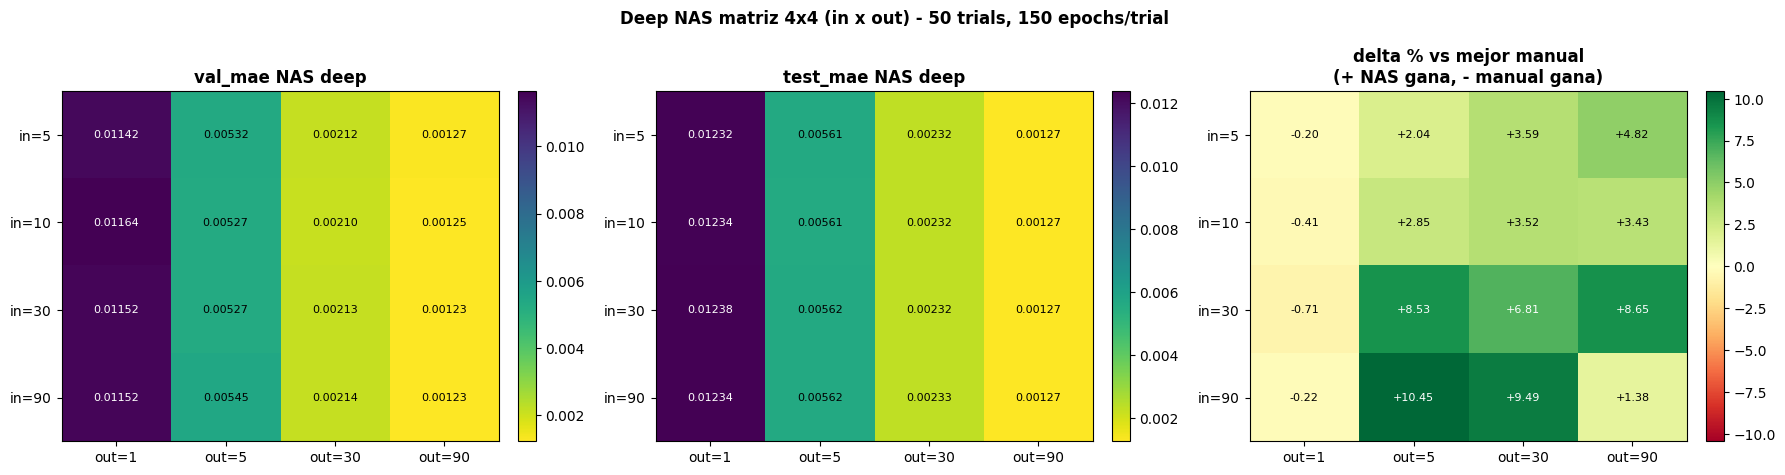


Heatmaps guardados en: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\autokeras_matriz_deep.png


In [39]:
deep_heatmap_path = RESULTS_DIR / "autokeras_matriz_deep.png"

if pivot_val is not None and pivot_test is not None and pivot_delta is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

    def _draw_heatmap(ax, data, title, cmap, fmt="{:.5f}", center=None):
        arr = data.values.astype(float)
        im = ax.imshow(arr, cmap=cmap, aspect="auto")
        if center is not None:
            vmax = np.nanmax(np.abs(arr)) if np.isfinite(np.nanmax(np.abs(arr))) else 1
            im.set_clim(-vmax, vmax)
        ax.set_xticks(range(len(data.columns)))
        ax.set_xticklabels([f"out={c}" for c in data.columns])
        ax.set_yticks(range(len(data.index)))
        ax.set_yticklabels([f"in={r}" for r in data.index])
        ax.set_title(title, fontweight="bold")
        for i in range(arr.shape[0]):
            for j in range(arr.shape[1]):
                v = arr[i, j]
                if np.isfinite(v):
                    ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=8,
                            color="white" if abs(v) > (np.nanmax(np.abs(arr)) * 0.6) else "black")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    _draw_heatmap(axes[0], pivot_val, "val_mae NAS deep", "viridis_r")
    _draw_heatmap(axes[1], pivot_test, "test_mae NAS deep", "viridis_r")
    _draw_heatmap(axes[2], pivot_delta, "delta % vs mejor manual\n(+ NAS gana, - manual gana)", "RdYlGn", fmt="{:+.2f}", center=0.0)

    fig.suptitle(f"Deep NAS matriz 4x4 (in x out) - {DEEP_MAX_TRIALS} trials, {DEEP_EPOCHS_PER_TRIAL} epochs/trial",
                 fontweight="bold", fontsize=12)
    fig.tight_layout()
    fig.savefig(deep_heatmap_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"\nHeatmaps guardados en: {deep_heatmap_path}")
else:
    print("[INFO] Sin heatmaps: completa primero el deep run para tener al menos un combo.")

In [40]:
deep_conclusions = []

if df_deep is None or len(df_deep) == 0:
    deep_conclusions.append("Sin resultados deep todavia. Ejecuta la celda de loop principal con DEEP_RUN_THIS=True.")
else:
    n_combos_done = len(df_deep)
    best_row = df_deep.sort_values("mae_val").iloc[0]
    deep_conclusions.append(
        f"Combos completados: {n_combos_done}/16. Mejor val_mae GLOBAL: in={int(best_row['input_window'])} out={int(best_row['output_window'])} "
        f"({best_row['metodo']}) val_mae={best_row['mae_val']:.6f}  test_mae={best_row['mae_test']:.6f}  params={int(best_row['n_params']):,}."
    )
    deep_conclusions.append(
        f"Este modelo se guarda en {best_row['model_path']} y es el candidato destacado para mencionar en la oral."
    )

    if df_manual_best is not None and "delta_pct_vs_manual_best" in df_deep.columns:
        df_with_delta = df_deep.merge(df_manual_best, on=["input_window", "output_window"], how="left")
        df_with_delta["delta_pct_vs_manual_best"] = 100.0 * (df_with_delta["mae_test_manual_best"] - df_with_delta["mae_test"]) / df_with_delta["mae_test_manual_best"]
        wins = df_with_delta[df_with_delta["delta_pct_vs_manual_best"] > 0.5]
        ties = df_with_delta[(df_with_delta["delta_pct_vs_manual_best"].abs() <= 0.5)]
        losses = df_with_delta[df_with_delta["delta_pct_vs_manual_best"] < -0.5]
        mean_delta = df_with_delta["delta_pct_vs_manual_best"].mean()
        deep_conclusions.append(
            f"NAS deep vs mejor manual: gana en {len(wins)} combos, empata (+-0.5%) en {len(ties)}, pierde en {len(losses)}. "
            f"Mejora media en la matriz: {mean_delta:+.2f}%."
        )
        if len(wins) > 0:
            best_win = wins.sort_values("delta_pct_vs_manual_best", ascending=False).iloc[0]
            deep_conclusions.append(
                f"Mayor mejora puntual: in={int(best_win['input_window'])} out={int(best_win['output_window'])} -> "
                f"{best_win['delta_pct_vs_manual_best']:+.2f}% sobre el manual (NAS test={best_win['mae_test']:.6f} vs manual {best_win['mae_test_manual_best']:.6f})."
            )
        if len(losses) > 0:
            worst = losses.sort_values("delta_pct_vs_manual_best").iloc[0]
            deep_conclusions.append(
                f"Peor combo para NAS: in={int(worst['input_window'])} out={int(worst['output_window'])} -> "
                f"{worst['delta_pct_vs_manual_best']:+.2f}% (manual {worst['mae_test_manual_best']:.6f} vs NAS {worst['mae_test']:.6f})."
            )
        if mean_delta > 1.0:
            deep_conclusions.append(
                "Lectura para la oral: el deep NAS bate de forma consistente al diseno manual. Argumento defendible "
                "para reconocer el valor del NAS cuando el budget computacional es generoso y la matriz cubre muchas ventanas."
            )
        elif mean_delta < -1.0:
            deep_conclusions.append(
                "Lectura para la oral: el diseno manual (mixtos del 06) bate al NAS deep en promedio. El conocimiento "
                "financiero condensado en las arquitecturas mixtas + Lopez de Prado es mas eficaz que la busqueda automatica."
            )
        else:
            deep_conclusions.append(
                "Lectura para la oral: NAS deep y manual convergen a calidad similar en la matriz 4x4. Sugiere que el "
                "SNR del problema (ruido de los retornos diarios) es el cuello de botella, no la arquitectura."
            )

print("Conclusiones del Deep NAS:")
print("=" * 80)
for i, line in enumerate(deep_conclusions, 1):
    print(f"{i}. {line}")

Conclusiones del Deep NAS:
1. Combos completados: 16/16. Mejor val_mae GLOBAL: in=90 out=90 (autokeras) val_mae=0.001225  test_mae=0.001270  params=68,087.
2. Este modelo se guarda en C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\models\autokeras_deep_in90_out90.keras y es el candidato destacado para mencionar en la oral.


## 8. Validación final + cheat sheet

In [41]:
checks_total = 0
checks_ok = 0


def _do(label, cond, detail=""):
    global checks_total, checks_ok
    checks_total += 1
    icono = "[OK]" if cond else "[FAIL]"
    print(f"{icono} {label} {detail}")
    if cond:
        checks_ok += 1


print("Validacion del notebook 09")
print("=" * 80)

_do("AutoKeras O Keras Tuner disponible", USE_AUTOKERAS or USE_KERAS_TUNER)
_do("CSV autokeras_resultados.csv existe", (RESULTS_DIR / "autokeras_resultados.csv").exists())
if (RESULTS_DIR / "autokeras_resultados.csv").exists():
    df_check = pd.read_csv(RESULTS_DIR / "autokeras_resultados.csv")
    _do("CSV >= 2 filas (NAS + al menos 1 referencia)", len(df_check) >= 2, f"(actual: {len(df_check)})")

_do("Figura comparativa existe", (RESULTS_DIR / "autokeras_comparativa.png").exists())
if best_model is not None:
    _do("Modelo NAS guardado", (MODELS_DIR / "autokeras_in90_out90.keras").exists())

_do("Deep NAS CSV existe (autokeras_matriz_deep.csv)", DEEP_CSV.exists())
if DEEP_CSV.exists():
    try:
        df_deep_check = pd.read_csv(DEEP_CSV)
        n_combos_done = int(df_deep_check["mae_val"].notna().sum())
    except Exception:
        n_combos_done = 0
    _do("Deep NAS >= 8 combos completados", n_combos_done >= 8, f"(actual: {n_combos_done}/16)")
_do("Heatmap deep generado", (RESULTS_DIR / "autokeras_matriz_deep.png").exists())

print("=" * 80)
print(f"Resultado: {checks_ok}/{checks_total} checks superados.")

Validacion del notebook 09
[OK] AutoKeras O Keras Tuner disponible 
[OK] CSV autokeras_resultados.csv existe 
[OK] CSV >= 2 filas (NAS + al menos 1 referencia) (actual: 4)
[OK] Figura comparativa existe 
[OK] Modelo NAS guardado 
[OK] Deep NAS CSV existe (autokeras_matriz_deep.csv) 
[OK] Deep NAS >= 8 combos completados (actual: 16/16)
[OK] Heatmap deep generado 
Resultado: 8/8 checks superados.


### Cheat sheet

**Subir el presupuesto de búsqueda**: cambia `MAX_TRIALS = 30` y `EPOCHS_PER_TRIAL = 80` en la celda 3 (búsqueda) y vuelve a ejecutar.

**Forzar AutoKeras (sin fallback)**:

```python
import autokeras as ak  # falla aqui si no esta instalado
USE_AUTOKERAS = True
USE_KERAS_TUNER = False
```

**Cargar el modelo NAS guardado**:

```python
from tensorflow.keras.models import load_model
nas = load_model(MODELS_DIR / "autokeras_in90_out90.keras", compile=False)
```

**Reutilizar el modelo NAS en `08_carteras_2025.ipynb`**:

```python
nas = load_model(MODELS_DIR / "autokeras_in90_out90.keras", compile=False)

def predict_returns_nas(window):
    if window.ndim == 2:
        window = window[np.newaxis, ...]
    X_n = scaler_X_inference.transform(window.reshape(-1, window.shape[-1])).reshape(window.shape).astype(np.float32)
    pred = nas.predict(X_n, verbose=0)
    if pred.ndim == 3:
        pred = pred.reshape(pred.shape[0], -1)
    return scaler_y_inference.inverse_transform(pred)[0]

PRED_MODELS["nas"] = predict_returns_nas
```

### Cierre del proyecto

Este es el último de los 3 notebooks de tu parte. Resumen del entregable completo:

| Notebook | Rol | Salida principal |
|---|---|---|
| `06_mixtos.ipynb` | Competición | 80 modelos + matriz competición + deep dive |
| `07_investigacion.ipynb` | Investigación | 12 técnicas comparadas, mejor preprocesado por celda |
| `08_carteras_2025.ipynb` | Aplicación práctica | 6 carteras backtested en 2025 |
| `09_autokeras_extra.ipynb` | Extra defensa | NAS vs manual, reflexión metodológica |

Siguiente paso: redactar PDF de presentación (5 min de oral, 5 min de Q&A).